After filtering: (362, 24)
tags: {'fix_mask': 181, 'fix_nonmask': 181}
eps: [np.float64(0.0001)]


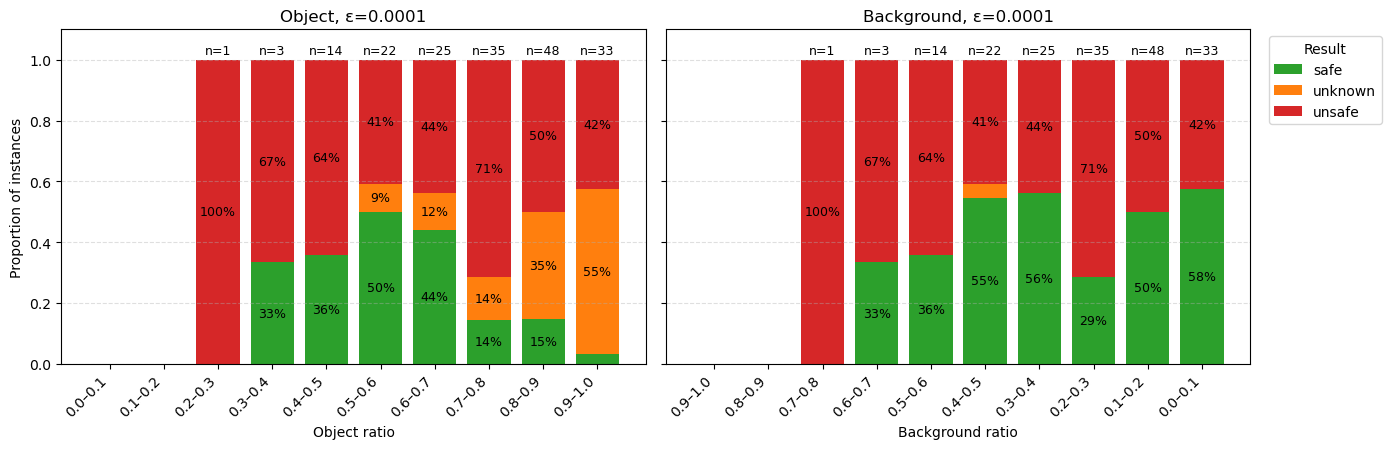

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------
# Load
# ---------------------------
df = pd.read_csv("csvs/ALL_vggnet_triplets_merged.csv")
# Force numeric
for c in ["eps", "k", "total", "segment_index", "num_changed"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# ---------------------------
# Keep only semantic + full-image element coverage
# total=150528 elements, full-image pixels => k = total/3 = 50176
# ---------------------------
keep_tags = ["fix_mask", "fix_nonmask"]
df = df[(df["total"] == 150528) & (df["tag"].isin(keep_tags))].copy()
df = df[df["k"] == (df["total"] // 3)].copy()

print("After filtering:", df.shape)
print("tags:", df["tag"].value_counts().to_dict())
print("eps:", sorted(df["eps"].dropna().unique()))

# ---------------------------
# Collapse results
# ---------------------------
def canon_result(x):
    s = str(x).lower()
    if "unsat" in s: return "safe"
    if "sat" in s:   return "unsafe"
    return "unknown"

df["result_cat"] = df["result"].apply(canon_result)

# Keys for pairing semantic
KEY = ["image", "segment_index", "eps", "k", "total"]

# ---------------------------
# Ratio bins
# ---------------------------
edges = np.linspace(0, 1.0, 11)
bin_labels = [f"{edges[i]:.1f}–{edges[i+1]:.1f}" for i in range(len(edges)-1)]
bin_labels_rev = list(reversed(bin_labels))

COLOR = {"safe": "#2ca02c", "unknown": "#ff7f0e", "unsafe": "#d62728"}
ORDER = ["safe", "unknown", "unsafe"]

def stacked_props(series_bins, series_result):
    counts = (
        pd.crosstab(series_bins, series_result)
        .reindex(bin_labels)
        .fillna(0)
    )
    n = counts.sum(axis=1).astype(int)
    props = counts.div(n.replace(0, np.nan), axis=0).fillna(0)
    return props, n

def paired_for_eps(eps_val):
    d = df[df["eps"] == eps_val].copy()

    obj = d[d["tag"] == "fix_nonmask"][KEY + ["num_changed", "result_cat"]].copy()
    bg  = d[d["tag"] == "fix_mask"][KEY + ["num_changed", "result_cat"]].copy()

    obj = obj.rename(columns={"num_changed": "obj_changed", "result_cat": "obj_result"})
    bg  = bg.rename(columns={"num_changed": "bg_changed",  "result_cat": "bg_result"})

    paired = obj.merge(bg, on=KEY, how="inner")

    paired["obj_ratio"] = paired["obj_changed"] / paired["total"]
    paired["bg_ratio"]  = paired["bg_changed"]  / paired["total"]

    paired["obj_bin"] = pd.cut(paired["obj_ratio"], bins=edges, labels=bin_labels, include_lowest=True)
    paired["bg_bin"]  = pd.cut(paired["bg_ratio"],  bins=edges, labels=bin_labels, include_lowest=True)

    obj_props, obj_n = stacked_props(paired["obj_bin"], paired["obj_result"])
    bg_props,  bg_n  = stacked_props(paired["bg_bin"],  paired["bg_result"])

    return obj_props, obj_n, bg_props, bg_n, len(paired)

def draw_stacked(ax, props, n_per_bin, xlabels, title, xlabel):
    x = np.arange(len(xlabels))
    bottom = np.zeros(len(xlabels))

    for lab in ORDER:
        vals = props.get(lab, pd.Series(0, index=xlabels)).reindex(xlabels).fillna(0).values
        ax.bar(x, vals, bottom=bottom, color=COLOR[lab], label=lab)
        for j, v in enumerate(vals):
            if v >= 0.06:
                ax.text(x[j], bottom[j] + v/2, f"{v*100:.0f}%", ha="center", va="center", fontsize=9)
        bottom += vals

    n_vals = n_per_bin.reindex(xlabels).fillna(0).astype(int).values
    for j, n in enumerate(n_vals):
        if n > 0:
            ax.text(x[j], 1.01, f"n={n}", ha="center", va="bottom", fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=45, ha="right")
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylim(0, 1.10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

# ---------------------------
# Plot
# ---------------------------
eps_values = sorted(df["eps"].dropna().unique())
if len(eps_values) == 0:
    raise ValueError("No eps values found.")

nrows = len(eps_values)
fig, axes = plt.subplots(nrows, 2, figsize=(14, 4.6 * nrows), sharey=True)

if nrows == 1:
    axes = np.array([axes])

for r, eps_val in enumerate(eps_values):
    obj_props, obj_n, bg_props, bg_n, n_pairs = paired_for_eps(eps_val)

    draw_stacked(axes[r, 0], obj_props, obj_n, bin_labels,
                 f"Object, ε={eps_val}", "Object ratio")

    bg_props_rev = bg_props.reindex(bin_labels_rev)
    bg_n_rev = bg_n.reindex(bin_labels_rev)
    draw_stacked(axes[r, 1], bg_props_rev, bg_n_rev, bin_labels_rev,
                 f"Background, ε={eps_val}", "Background ratio")

for r in range(nrows):
    axes[r, 0].set_ylabel("Proportion of instances")

axes[0, 1].legend(title="Result", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
fig.savefig("pdfs/object_bg_proportion_of_instances_vs_ratio.pdf", bbox_inches="tight")

plt.show()

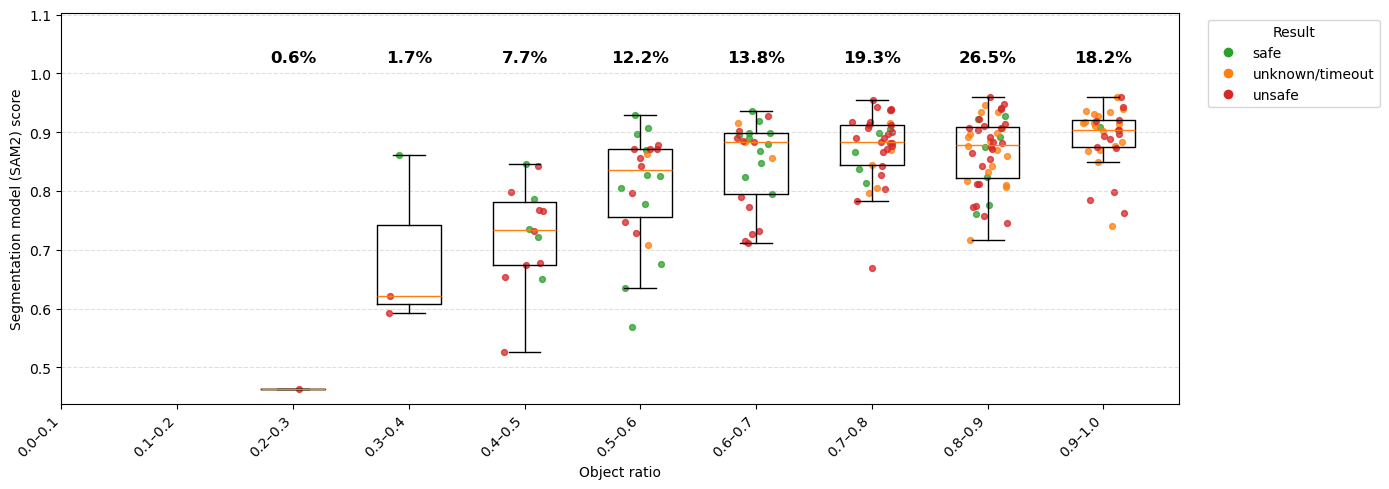

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Filter: semantic only + full image only
# -------------------------
df = df[(df["total"] == 150528) & (df["tag"].isin(["fix_mask", "fix_nonmask"]))].copy()
df = df[df["k"] == (df["total"] // 3)].copy()   # full image only

# numeric safety
for c in ["num_changed", "score", "eps", "k", "total", "segment_index"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -------------------------
# Result collapse
# -------------------------
def canon_result(x):
    s = str(x).lower()
    if "unsat" in s: return "safe"
    if "sat" in s:   return "unsafe"
    return "unknown/timeout"

df["result_cat"] = df["result"].apply(canon_result)

COLOR = {
    "safe": "#2ca02c",
    "unknown/timeout": "#ff7f0e",
    "unsafe": "#d62728",
}
ORDER = ["safe", "unsafe", "unknown/timeout"]

# =========================
# Pair object/background
# =========================
KEY = ["image", "segment_index", "eps", "k", "total"]

obj = df[df["tag"] == "fix_nonmask"][KEY + ["num_changed", "score", "result_cat"]].copy()
bg  = df[df["tag"] == "fix_mask"][KEY + ["num_changed", "score", "result_cat"]].copy()

obj = obj.rename(columns={"num_changed": "obj_changed", "score": "obj_score", "result_cat": "obj_result"})
bg  = bg.rename(columns={"num_changed": "bg_changed",  "score": "bg_score",  "result_cat": "bg_result"})

paired = obj.merge(bg, on=KEY, how="inner")

# -------------------------
# Object ratio defines bins
# -------------------------
paired["obj_ratio"] = paired["obj_changed"] / paired["total"]

bin_edges = np.linspace(0, 1.0, 11)
bin_labels = [f"{i/10:.1f}–{(i+1)/10:.1f}" for i in range(10)]

paired["obj_bin"] = pd.cut(
    paired["obj_ratio"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
)

# -------------------------
# Combine Object + Background
# -------------------------
paired["score_combined"] = paired[["obj_score", "bg_score"]].mean(axis=1)

def combine_result(row):
    if row["obj_result"] == "unsafe" or row["bg_result"] == "unsafe":
        return "unsafe"
    if row["obj_result"] == "unknown/timeout" or row["bg_result"] == "unknown/timeout":
        return "unknown/timeout"
    return "safe"

paired["result_combined"] = paired.apply(combine_result, axis=1)

# -------------------------
# Percentage per bin (of TOTAL paired)
# -------------------------
total_n = len(paired)

counts = (
    paired["obj_bin"]
    .value_counts()
    .reindex(bin_labels)
    .fillna(0)
)

percent_total = 100.0 * counts / (total_n if total_n > 0 else 1)

scores_by_bin = [
    paired.loc[paired["obj_bin"] == b, "score_combined"].dropna().values
    for b in bin_labels
]

# =========================
# Plot
# =========================
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(bin_labels))

# Boxplot for score
ax.boxplot(
    scores_by_bin,
    positions=x,
    widths=0.55,
    showfliers=False,
    manage_ticks=False,
)

# Jitter points colored by result
rng = np.random.default_rng(0)
for i, b in enumerate(bin_labels):
    sub = paired[paired["obj_bin"] == b]
    for lab in ORDER:
        pts = sub[sub["result_combined"] == lab]["score_combined"].dropna().values
        if len(pts) == 0:
            continue
        jitter = rng.uniform(-0.18, 0.18, size=len(pts))
        ax.scatter(
            np.full(len(pts), x[i]) + jitter,
            pts,
            s=18,
            alpha=0.75,
            color=COLOR[lab],
        )

# ---- % of TOTAL above each bin (bigger + higher)
y_top = ax.get_ylim()[1]

for i, b in enumerate(bin_labels):
    p = percent_total.loc[b]
    if p > 0:
        ax.text(
            i,
            y_top * 1.03,
            f"{p:.1f}%",
            ha="center",
            va="bottom",
            fontsize=12,
            fontweight="bold",
        )

# headroom for top text
ax.set_ylim(ax.get_ylim()[0], y_top * 1.12)

# -------------------------
# Labels / legend
# -------------------------
ax.set_xticks(x)
ax.set_xticklabels(bin_labels, rotation=45, ha="right")
ax.set_xlabel("Object ratio")
ax.set_ylabel("Segmentation model (SAM2) score")

ax.grid(axis="y", linestyle="--", alpha=0.4)

handles = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR["safe"], markersize=8, label="safe"),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR["unknown/timeout"], markersize=8, label="unknown/timeout"),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COLOR["unsafe"], markersize=8, label="unsafe"),
]

ax.legend(handles=handles, title="Result", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()

plt.tight_layout()

fig.savefig("pdfs/object_bg_score_vs_ratio.pdf", bbox_inches="tight")
plt.show()